### Step 1：Cart-Pole的物理动力学仿真

根据课程已有代码，我们可以构建Cart-Pole的物理动力学仿真，并在meshcat窗口里面看到动画，以比较直观的方式入手，看一下Cart-Pole的运动方式，也可以手动设置外部输入u来改变Cart-Pole的运动状态。

In [5]:
# 环境设置
import numpy as np
import matplotlib.pyplot as plt
from pydrake.all import (
    AddMultibodyPlantSceneGraph,
    ControllabilityMatrix,
    DiagramBuilder,
    DirectCollocation,
    LeafSystem,
    Linearize,
    LinearQuadraticRegulator,
    MeshcatVisualizer,
    MultibodyPlant,
    Parser,
    PiecewisePolynomial,
    Simulator,
    SnoptSolver,
    Solve,
    StartMeshcat,
    )
from underactuated import ConfigureParser, running_as_notebook
from underactuated.meshcat_utils import MeshcatSliders

在仿真中，我们可以观察Cart-Pole的运动（给了初始值theta = 1.0 rad），我们发现没有外力情况下，Cart-Pole来回简谐运动。  
在INFO:drake:Meshcat listening for connections at打开网址，在controller里面按stop simulation可以停止并画图，不然代码会有错误。

<>:73: SyntaxWarning: invalid escape sequence '\d'
<>:76: SyntaxWarning: invalid escape sequence '\d'
<>:73: SyntaxWarning: invalid escape sequence '\d'
<>:76: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_9116/287268192.py:73: SyntaxWarning: invalid escape sequence '\d'
  axes[1,0].set_title('Cart Velocity $\dot{x}$ (m/s)'); axes[1,0].grid()
/tmp/ipykernel_9116/287268192.py:76: SyntaxWarning: invalid escape sequence '\d'
  axes[1,1].set_title('Pole Angular Velocity $\dot{\\theta}$ (rad/s)'); axes[1,1].grid()
INFO:drake:Meshcat listening for connections at http://localhost:7001


Press 'Stop Simulation' in MeshCat to continue.


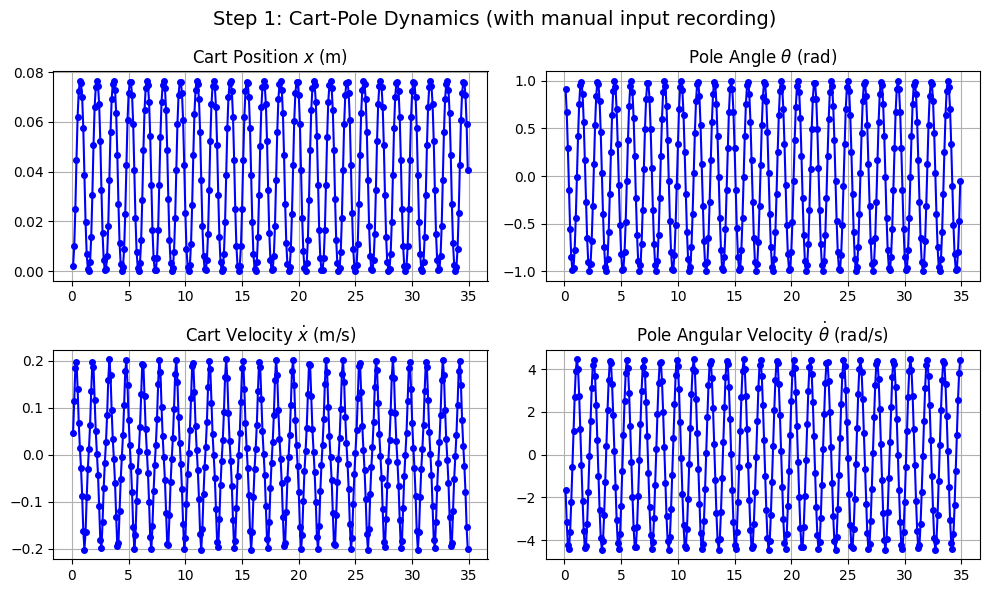

 记录完成：共 349 个采样点，总时长 34.90 s


In [6]:
#  仿真
# 启动 Meshcat（全局只运行一次）
meshcat = StartMeshcat()
def cartpole_step1():
    builder = DiagramBuilder()
    plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.0)
    parser = Parser(plant)
    ConfigureParser(parser)  
    parser.AddModelsFromUrl("package://underactuated/models/cartpole.urdf")
    plant.Finalize()

    meshcat.Delete()
    meshcat.Set2dRenderMode(xmin=-2.5, xmax=2.5, ymin=-1.0, ymax=2.5)
    MeshcatVisualizer.AddToBuilder(builder, scene_graph, meshcat)

    meshcat.AddSlider(
        "u",
        min=-5,
        max=5,
        step=0.1,
        value=0.0,
        decrement_keycode="ArrowLeft",
        increment_keycode="ArrowRight",
    )
    force_system = builder.AddSystem(MeshcatSliders(meshcat, ["u"]))
    builder.Connect(
        force_system.get_output_port(), plant.get_actuation_input_port()
    )

    diagram = builder.Build()
    simulator = Simulator(diagram)
    context = simulator.get_mutable_context()

    plant_context = plant.GetMyMutableContextFromRoot(context)
    plant.SetPositionsAndVelocities(plant_context, [0.0, 1.0, 0.0, 0.0])
    # 顺序: [x, theta, x_dot, theta_dot]

    # 记录状态历史 
    times = []
    states = []

    if running_as_notebook:
        simulator.set_target_realtime_rate(1.0)
        print("Press 'Stop Simulation' in MeshCat to continue.")
        meshcat.AddButton("Stop Simulation", "Escape")
        
        while meshcat.GetButtonClicks("Stop Simulation") < 1:
            t_next = simulator.get_context().get_time() + 0.1
            simulator.AdvanceTo(t_next)
            # 每0.1秒记录一次
            times.append(context.get_time())
            states.append(plant.GetPositionsAndVelocities(plant_context).copy())
    else:
        simulator.AdvanceTo(0.1)
        times.append(context.get_time())
        states.append(plant.GetPositionsAndVelocities(plant_context).copy())

    meshcat.DeleteAddedControls()
    
    #画图
    if len(states) > 1:
        states = np.array(states)
        times = np.array(times)

        fig, axes = plt.subplots(2, 2, figsize=(10, 6))
        axes[0,0].plot(times, states[:,0], 'b-o', markersize=4)
        axes[0,0].set_title('Cart Position $x$ (m)'); axes[0,0].grid()

        axes[0,1].plot(times, states[:,1], 'b-o', markersize=4)
        axes[0,1].set_title('Pole Angle $\\theta$ (rad)'); axes[0,1].grid()

        axes[1,0].plot(times, states[:,2], 'b-o', markersize=4)
        axes[1,0].set_title('Cart Velocity $\dot{x}$ (m/s)'); axes[1,0].grid()

        axes[1,1].plot(times, states[:,3], 'b-o', markersize=4)
        axes[1,1].set_title('Pole Angular Velocity $\dot{\\theta}$ (rad/s)'); axes[1,1].grid()

        plt.suptitle("Step 1: Cart-Pole Dynamics (with manual input recording)", fontsize=14)
        plt.tight_layout()
        plt.show()

        print(f" 记录完成：共 {len(times)} 个采样点，总时长 {times[-1]:.2f} s")

# 运行
cartpole_step1()

我们也可以手动增加u，观察Cart-Pole运动情况。结束仿真后可以通过图象观察四个变量的变化情况（这里每0.1s采样一次，比较贴合，如果手动调整u的速度比较快的话，也可以再增加采样频率，这样图会比较准确。